In [1]:
import pandas

from scipy.stats import poisson

from matplotlib import pyplot
from matplotlib.dates import DateFormatter
from matplotlib.transforms import Bbox

import boto3

# Read Week History

In [2]:
history = 'history-2026-w11.csv'
df = pandas.read_csv(history, parse_dates=['Datetime'])
df

,Datetime,CPM
0,2026-03-15 08:28:07,14
1,2026-03-15 08:29:07,10
2,2026-03-15 08:30:07,15
3,2026-03-15 08:31:07,13
4,2026-03-15 08:32:07,1
...,...,...
10059,2026-03-22 08:07:07,8
10060,2026-03-22 08:08:07,6
10061,2026-03-22 08:09:07,20
10062,2026-03-22 08:10:07,9


# Plot Week History

In [3]:
dt = df['Datetime']
cpm = df['CPM']

In [4]:
title = dt.iloc[0].strftime('Week %U of %Y · Honolulu')
title

'Week 11 of 2026 · Honolulu'

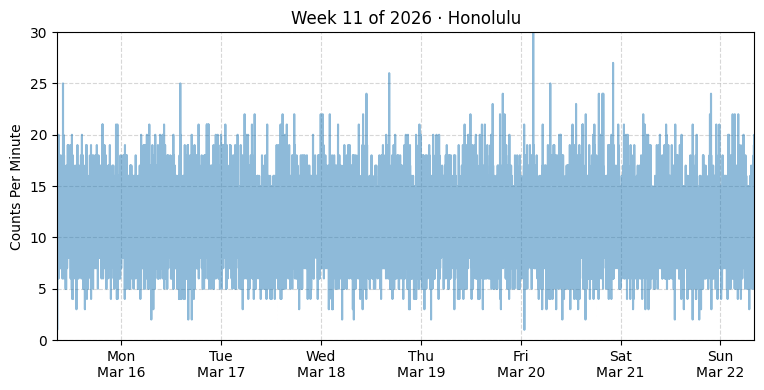

In [5]:
fig_a, ax = pyplot.subplots(1, 1, figsize=(9, 4))

ax.plot(dt, cpm, color='#1f77b4', alpha=0.5)

ax.set_xlim(dt.loc[0], dt.iloc[-1])
ax.set_ylim(0, 30)

ax.xaxis.set_major_formatter(DateFormatter('%a\n%b %d'))
ax.grid(True, linestyle='--', alpha=0.5)

ax.set_title(title)
ax.set_ylabel('Counts Per Minute');

# Plot Week Histogram

In [6]:
stats = (
    f'x̄ = {cpm.mean():.3f}\n'
    f'σ² = {cpm.var():.3f}\n'
    f'min = {cpm.min():d}\n'
    f'max = {cpm.max():d}')

In [7]:
histogram = cpm.value_counts(normalize=True).sort_index()

In [8]:
fit = pandas.Series(poisson.pmf(range(1000), cpm.mean()))

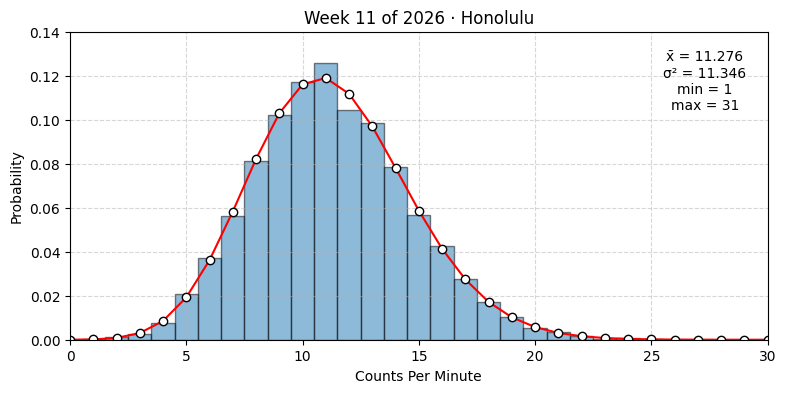

In [9]:
fig_b, ax = pyplot.subplots(1, 1, figsize=(9, 4))

ax.bar(histogram.index, histogram.values,
    width=1.0, align='center', color='#1f77b4', alpha=0.5, edgecolor='black')
ax.plot(fit.index, fit.values,
    color='red', marker='o', markerfacecolor='white', markeredgecolor='black')
ax.text(0.91, 0.84, stats,
    transform=ax.transAxes, va='center', ha='center')

ax.set_xlim(0, 30)
ax.set_ylim(0, 0.14)
ax.grid(True, linestyle='--', alpha=0.5)

ax.set_title(title)
ax.set_xlabel('Counts Per Minute')
ax.set_ylabel('Probability');

# Note Week

In [10]:
# notes = ''

In [17]:
# notes = "There was lots of rain this week. Is the 31 cpm spike on Friday 3AM related?"

# Export And Upload Week

In [18]:
file_a = dt.iloc[0].strftime('plot-a-%Y-w%U.png')
file_b = dt.iloc[0].strftime('plot-b-%Y-w%U.png')
file_c = dt.iloc[0].strftime('notes-%Y-w%U.txt')

display(file_a, file_b, file_c)

'plot-a-2026-w11.png'

'plot-b-2026-w11.png'

'notes-2026-w11.txt'

In [19]:
bbox = Bbox.from_bounds(0.4, -0.1, 8.2, 4.0)
fig_a.savefig(file_a, dpi=300, bbox_inches=bbox)
fig_b.savefig(file_b, dpi=300, bbox_inches=bbox)

In [20]:
with open(file_c, "w") as file:
    file.write(notes)

In [21]:
bucket = boto3.resource('s3').Bucket('hnlrad')
bucket.upload_file(file_a, file_a)
bucket.upload_file(file_b, file_b)
bucket.upload_file(file_c, file_c)